In [1]:
import pandas as pd

listings = pd.read_parquet("../data/interim/listings_final2_silver.parquet")
print(listings.shape)

(30259, 95)


#Feature leakage check

In [2]:
ml_data = listings.copy()

# Check every column for leakage risk — anything derived FROM price must be excluded
leak_check = ['estimated_revenue', 'price_per_bedroom', 'price_quote_total_price', 'price_quote_price_per_night']
for col in leak_check:
    if col in ml_data.columns:
        corr_with_price = ml_data[[col, 'price']].corr().iloc[0,1]
        print(f"{col}: correlation with price = {corr_with_price:.3f}")

estimated_revenue: correlation with price = 0.522
price_per_bedroom: correlation with price = 0.785
price_quote_total_price: correlation with price = 0.736
price_quote_price_per_night: correlation with price = 1.000


#Build the feature set

In [3]:
feature_cols = [
    'accommodates', 'bedrooms', 'bathrooms', 'minimum_nights', 'availability_365',
    'review_scores_rating', 'number_of_reviews', 'room_type', 'property_type_group',
    'neighbourhood_group_cleansed', 'host_is_superhost', 'host_tenure_years_est'
]

ml_df = ml_data[feature_cols + ['price']].dropna()
print(f"Final modeling dataset: {ml_df.shape}")
print(ml_df.dtypes)

Final modeling dataset: (8415, 13)
accommodates                      int64
bedrooms                        float64
bathrooms                       float64
minimum_nights                  float64
availability_365                  int64
review_scores_rating            float64
number_of_reviews                 int64
room_type                           str
property_type_group                 str
neighbourhood_group_cleansed        str
host_is_superhost                   str
host_tenure_years_est             Int64
price                           float64
dtype: object


#Encode categoricals + train/test split

In [4]:
from sklearn.model_selection import train_test_split
import pandas as pd

ml_encoded = pd.get_dummies(
    ml_df,
    columns=['room_type', 'property_type_group', 'neighbourhood_group_cleansed', 'host_is_superhost'],
    drop_first=True
)

X = ml_encoded.drop(columns=['price'])
y = ml_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Features: {X.columns.tolist()}")

Train set: (6732, 20), Test set: (1683, 20)
Features: ['accommodates', 'bedrooms', 'bathrooms', 'minimum_nights', 'availability_365', 'review_scores_rating', 'number_of_reviews', 'host_tenure_years_est', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'property_type_group_Hotel/B&B', 'property_type_group_Other', 'property_type_group_Private room', 'property_type_group_Shared room', 'neighbourhood_group_cleansed_Brooklyn', 'neighbourhood_group_cleansed_Manhattan', 'neighbourhood_group_cleansed_Queens', 'neighbourhood_group_cleansed_Staten Island', 'host_is_superhost_t']


#Train all three models, evaluate consistently

In [5]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    print(f"{name}: MAE=${mae:.2f}, RMSE=${rmse:.2f}, R²={r2:.3f}")

results_df = pd.DataFrame(results)

Linear Regression: MAE=$139.63, RMSE=$369.37, R²=0.277


C:\Users\SKY PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\SKY PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\SKY PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.paralle

Random Forest: MAE=$116.79, RMSE=$286.95, R²=0.564
XGBoost: MAE=$117.82, RMSE=$324.32, R²=0.443


#SHAP explainability + cross-reference to OLS

In [7]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable


C:\Users\SKY PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=3>
  res = process_handler(cmd, _system_body)
C:\Users\SKY PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=4>
  res = process_handler(cmd, _system_body)
C:\Users\SKY PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=5>
  res = process_handler(cmd, _system_body)


C:\Users\SKY PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\SKY PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\shap\plots\colors\_colors.py:47: PendingDeprecationWarning: The set_bad function will be deprecated in a future version. Use cmap.with_extremes(bad=...) or Colormap(bad=...) instead.
  red_blue.set_bad(gray_rgb.tolist(), 1.0)
C:\Users\SKY PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\shap\plots\colors\_colors.py:48: PendingDeprecationWarning: The set_over function will be deprecated in a future version. Use cmap.with_extremes(over

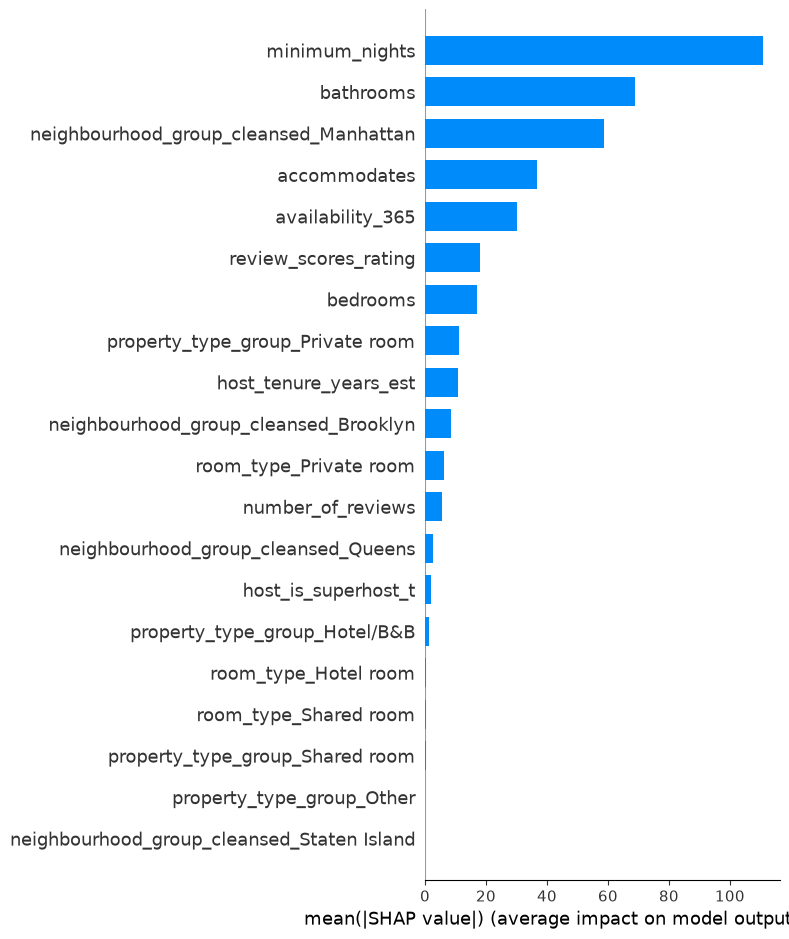

In [8]:
import shap

best_model = models['Random Forest']
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
import matplotlib.pyplot as plt
plt.tight_layout()


import os

plt.savefig("../reports/figures/fig13_shap_importance.png", dpi=150, bbox_inches='tight')

plt.show()

#residual analysis by segment

In [9]:
best_model = models['Random Forest']
test_preds = best_model.predict(X_test)
residuals = y_test - test_preds

residual_df = X_test.copy()
residual_df['residual'] = residuals
residual_df['abs_residual'] = residuals.abs()

# By borough
for col in ['neighbourhood_group_cleansed_Manhattan', 'neighbourhood_group_cleansed_Brooklyn', 'neighbourhood_group_cleansed_Queens']:
    print(f"{col}=1 mean abs residual: {residual_df[residual_df[col]==1]['abs_residual'].mean():.2f}")
print(f"Baseline (Bronx) mean abs residual: {residual_df[(residual_df['neighbourhood_group_cleansed_Manhattan']==0) & (residual_df['neighbourhood_group_cleansed_Brooklyn']==0) & (residual_df['neighbourhood_group_cleansed_Queens']==0)]['abs_residual'].mean():.2f}")

neighbourhood_group_cleansed_Manhattan=1 mean abs residual: 146.37
neighbourhood_group_cleansed_Brooklyn=1 mean abs residual: 99.04
neighbourhood_group_cleansed_Queens=1 mean abs residual: 93.21
Baseline (Bronx) mean abs residual: 65.13


C:\Users\SKY PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\SKY PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\SKY PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.paralle

##6.3  Host & Listinng Segmentation 

#Select and scale features for clustering

In [10]:
from sklearn.preprocessing import StandardScaler

cluster_features = ['price', 'accommodates', 'bedrooms', 'bathrooms',
                     'occupancy_rate', 'review_scores_rating', 'availability_365']

cluster_df = listings[cluster_features].dropna()
print(f"Clustering dataset: {cluster_df.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

Clustering dataset: (8415, 7)


#Find the right number of clusters (elbow method + silhouette score)

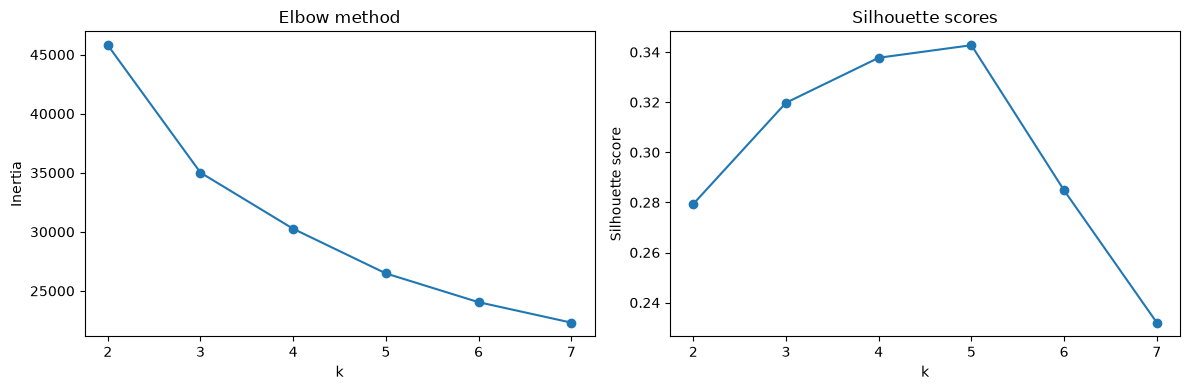

k=2: silhouette=0.279
k=3: silhouette=0.320
k=4: silhouette=0.338
k=5: silhouette=0.343
k=6: silhouette=0.285
k=7: silhouette=0.232


In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouette_scores = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(k_range, inertias, marker='o')
axes[0].set_title('Elbow method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette_scores, marker='o')
axes[1].set_title('Silhouette scores')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
plt.tight_layout()

import os

plt.savefig("../reports/figures/fig14_cluster_selection.png", dpi=150, bbox_inches='tight')

plt.show()

for k, s in zip(k_range, silhouette_scores):
    print(f"k={k}: silhouette={s:.3f}")

#Fit final model with k=5 and profile the clusters

In [12]:
final_km = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_df = cluster_df.copy()
cluster_df['cluster'] = final_km.fit_predict(X_scaled)

cluster_profile = cluster_df.groupby('cluster').agg(
    n=('price', 'count'),
    avg_price=('price', 'mean'),
    avg_accommodates=('accommodates', 'mean'),
    avg_bedrooms=('bedrooms', 'mean'),
    avg_bathrooms=('bathrooms', 'mean'),
    avg_occupancy=('occupancy_rate', 'mean'),
    avg_rating=('review_scores_rating', 'mean'),
    avg_availability=('availability_365', 'mean')
).round(2)

print(cluster_profile)

            n  avg_price  avg_accommodates  avg_bedrooms  avg_bathrooms  \
cluster                                                                   
0         215     220.79              3.28          1.44           1.20   
1        1185     594.07              6.98          3.09           2.08   
2        4076     241.56              3.04          1.39           1.06   
3          28    4967.46             10.29          5.39           3.95   
4        2911     241.06              2.94          1.39           1.10   

         avg_occupancy  avg_rating  avg_availability  
cluster                                               
0                 0.24        2.47            278.17  
1                 0.28        4.81            263.09  
2                 0.15        4.77            310.60  
3                 0.26        4.88            268.57  
4                 0.65        4.81            128.36  
